<a href="https://colab.research.google.com/github/1zizu/Challenge-Alura-Telecom---Data-Science-2/blob/main/challenge_alura_telecom_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extração dos Dados

In [2]:
import pandas as pd
import requests


In [3]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

In [4]:
import requests

response = requests.get(url)
dados = response.json()

In [5]:
df = pd.DataFrame(dados)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# Transformação dos Dados ETL

In [6]:
df = pd.json_normalize(dados)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Estrutura

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [8]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

# Correção / Limpeza

In [9]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


## Variáveis relevantes para análise de churn

Após explorar o dataset e consultar o dicionário de dados, as seguintes variáveis foram identificadas como relevantes para entender a evasão de clientes:

- Churn
- customer.tenure
- account.Contract
- account.Charges.Monthly
- account.Charges.Total
- account.PaymentMethod
- internet.InternetService
- internet.TechSupport
- internet.OnlineSecurity

# Verificando Inconsistências nos Dados

In [10]:
df.isnull().sum()


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for coluna in df.select_dtypes(include='object').columns:
  print(coluna)
  print(df[coluna].unique())
  print('---')

customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
---
Churn
['No' 'Yes' '']
---
customer.gender
['Female' 'Male']
---
customer.Partner
['Yes' 'No']
---
customer.Dependents
['Yes' 'No']
---
phone.PhoneService
['Yes' 'No']
---
phone.MultipleLines
['No' 'Yes' 'No phone service']
---
internet.InternetService
['DSL' 'Fiber optic' 'No']
---
internet.OnlineSecurity
['No' 'Yes' 'No internet service']
---
internet.OnlineBackup
['Yes' 'No' 'No internet service']
---
internet.DeviceProtection
['No' 'Yes' 'No internet service']
---
internet.TechSupport
['Yes' 'No' 'No internet service']
---
internet.StreamingTV
['Yes' 'No' 'No internet service']
---
internet.StreamingMovies
['No' 'Yes' 'No internet service']
---
account.Contract
['One year' 'Month-to-month' 'Two year']
---
account.PaperlessBilling
['Yes' 'No']
---
account.PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
---


In [13]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


# Tratando as Inconsistências

In [14]:
df = df.dropna(subset=['account.Charges.Total'])

In [15]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [16]:
df.shape

(7256, 21)

# Coluna Contas Diárias

In [17]:
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30

In [18]:
df[['account.Charges.Monthly', 'Contas_Diarias']].head()

,account.Charges.Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


# Padronização e Transformação de Dados

In [19]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [20]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


# Carga e Análise (L - Load & Analysis)

# Análise Descritiva

In [21]:
df.describe()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,32.395535,64.755423,2280.634213,2.158514
std,0.441782,0.3693,24.558067,30.125739,2268.632997,1.004191
min,0.000000,0.0000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,0.0000,9.000000,35.450000,400.225000,1.181667
50%,0.000000,0.0000,29.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.0000,55.000000,89.900000,3785.300000,2.996667
max,1.000000,1.0000,72.000000,118.750000,8684.800000,3.958333


In [22]:
df.describe(include='object')

,customerID,customer.gender,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod
count,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256
unique,7256,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,3669,3747,5086,6551,3490,3198,3607,3181,3194,3581,2895,2866,4005,4308,2445


In [23]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [24]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0.0,0.734215
1.0,0.265785


# Distribuição da Evasão

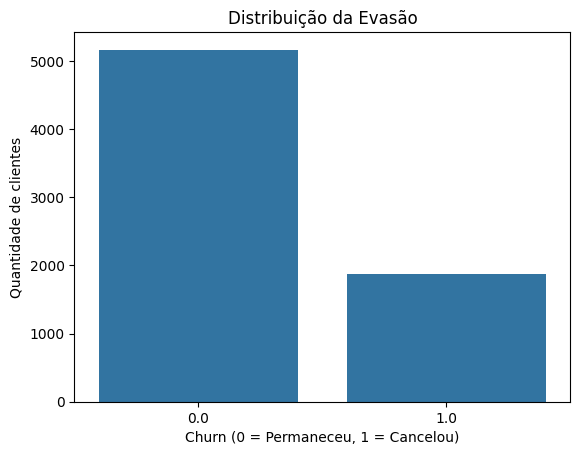

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)

plt.title('Distribuição da Evasão')
plt.xlabel('Churn (0 = Permaneceu, 1 = Cancelou)')
plt.ylabel('Quantidade de clientes')

plt.show()

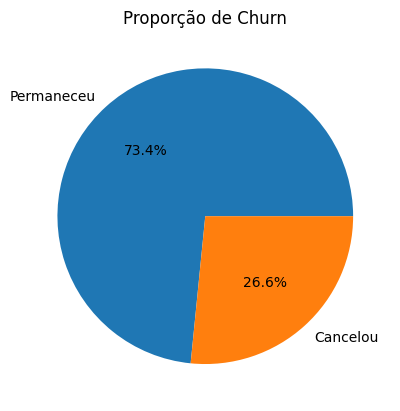

In [26]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels = ['Permaneceu', 'Cancelou'],
)

plt.title('Proporção de Churn')
plt.ylabel('')

plt.show()

# Contagem de Evasão por Variáveis Categóricas

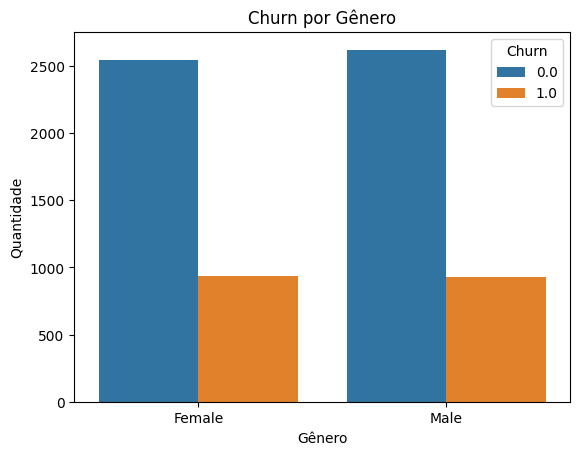

In [27]:
sns.countplot(x='customer.gender', hue='Churn', data=df)

plt.title('Churn por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')

plt.show()

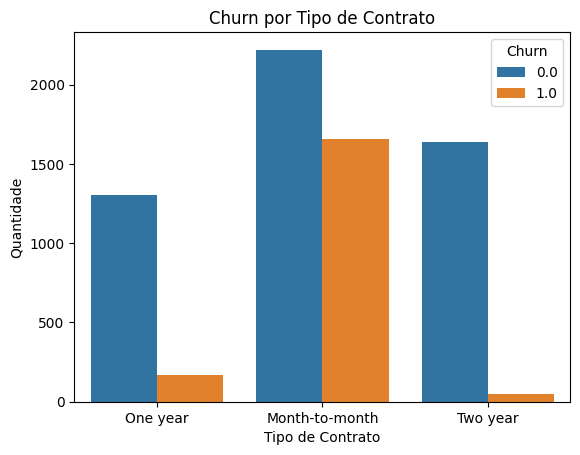

In [28]:
sns.countplot(x='account.Contract', hue='Churn', data=df)

plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade')

plt.show()

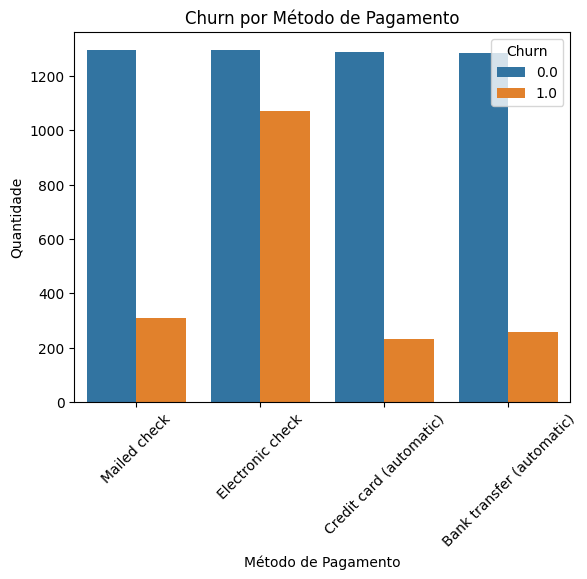

In [29]:
sns.countplot(x='account.PaymentMethod', hue='Churn', data=df)

plt.title('Churn por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.show()

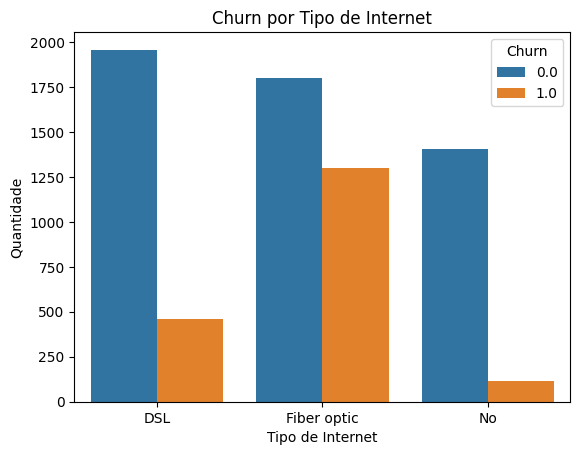

In [30]:
sns.countplot(x='internet.InternetService', hue='Churn', data=df)

plt.title('Churn por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Quantidade')

plt.show()

# Contagem de Evasão por Variáveis Numéricas

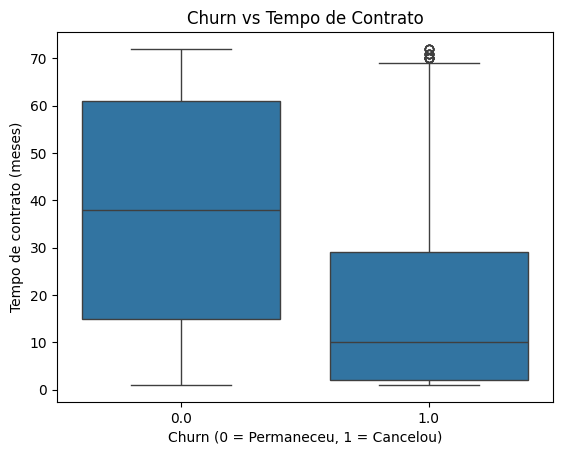

In [31]:
sns.boxplot(x='Churn', y='customer.tenure', data=df)

plt.title('Churn vs Tempo de Contrato')
plt.xlabel('Churn (0 = Permaneceu, 1 = Cancelou)')
plt.ylabel('Tempo de contrato (meses)')

plt.show()

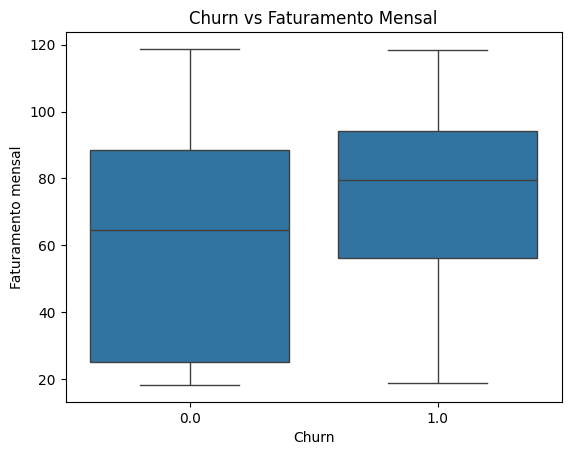

In [32]:
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df)

plt.title('Churn vs Faturamento Mensal')
plt.xlabel('Churn')
plt.ylabel('Faturamento mensal')

plt.show()

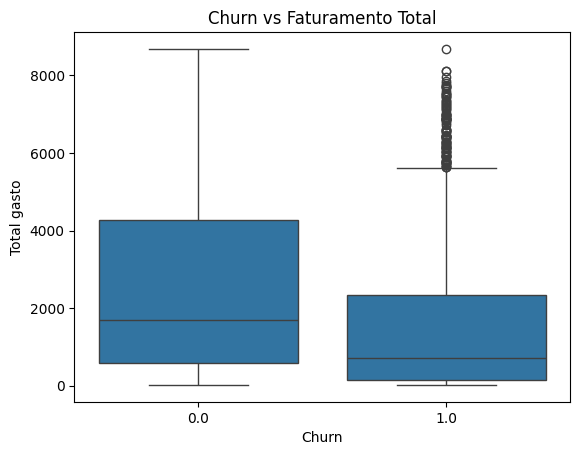

In [33]:
sns.boxplot(x='Churn', y='account.Charges.Total', data=df)

plt.title('Churn vs Faturamento Total')
plt.xlabel('Churn')
plt.ylabel('Total gasto')

plt.show()

# Interpretação:

Por meio dos gráficos foi possível concluir que:
* Clientes que cancelam têm menos tempo de contrato
* Clientes que cancelam têm gastos totais menores
* clientes que cancelam às vezes têm mensalidades mais altas

# Relatório Final

# Introdução

Este projeto tem como objetivo analisar os dados de clientes da empresa Telecom X para compreender os fatores que contribuem para a evasão de clientes, conhecida como churn. A empresa enfrenta um alto índice de cancelamentos e precisa identificar padrões que expliquem esse comportamento.

A partir da análise dos dados, buscamos identificar características dos clientes que estão mais associadas à evasão, permitindo que a empresa desenvolva estratégias mais eficazes para retenção de clientes.




# Limpeza e Tratamento de Dados

O primeiro passo do projeto consistiu na extração dos dados a partir de uma API disponibilizada pela Telecom X. Esses dados estavam originalmente no formato JSON e foram convertidos para uma estrutura de tabela utilizando a biblioteca Pandas em Python.

Após a importação dos dados, foi realizada uma etapa de exploração inicial para compreender a estrutura do conjunto de dados, os tipos de variáveis existentes e possíveis inconsistências. Durante essa verificação foi identificado que a coluna referente ao valor total gasto pelos clientes apresentava valores ausentes e estava armazenada como texto. Esses valores foram convertidos para formato numérico e os registros com dados ausentes foram removidos para evitar problemas nas análises posteriores.

Também foi criada uma nova variável chamada Contas Diarias, calculada a partir da divisão do valor de faturamento mensal por trinta dias. Essa transformação permitiu observar o comportamento de cobrança dos clientes em uma escala diária.

Além disso, algumas variáveis categóricas foram padronizadas para facilitar a análise, como a conversão da variável de evasão para formato numérico, em que zero representa clientes que permaneceram e um representa clientes que cancelaram o serviço.

Essas etapas garantiram que o conjunto de dados estivesse limpo, consistente e preparado para as análises exploratórias.



# Análise Exploratória de Dados

A análise exploratória foi realizada com o objetivo de identificar padrões nos dados e compreender melhor o comportamento dos clientes em relação à evasão. Foram utilizadas estatísticas descritivas e visualizações gráficas para analisar tanto variáveis categóricas quanto variáveis numéricas.

Inicialmente foi analisada a distribuição geral da evasão de clientes. Os resultados mostraram que aproximadamente setenta e três por cento dos clientes permaneceram com os serviços da empresa, enquanto cerca de vinte e seis por cento cancelaram o contrato. Isso indica que aproximadamente um em cada quatro clientes decide encerrar seu relacionamento com a empresa.

Em seguida foram analisadas variáveis categóricas para verificar se certos perfis de clientes apresentavam maior tendência à evasão. Observou-se que o gênero dos clientes não apresentou diferença significativa na taxa de cancelamento. Por outro lado, o tipo de contrato mostrou um padrão muito relevante. Clientes que possuem contratos mensais apresentaram taxas muito mais altas de cancelamento em comparação com clientes que possuem contratos anuais ou de dois anos.

A análise do método de pagamento também revelou um padrão importante. Clientes que utilizam pagamento por meio de cheque eletrônico apresentaram uma proporção maior de cancelamento quando comparados com clientes que utilizam métodos automáticos de pagamento.

Também foi analisado o tipo de serviço de internet contratado. Observou-se que clientes que utilizam internet de fibra óptica apresentam maior incidência de cancelamento em comparação com clientes que utilizam outros tipos de conexão ou que não possuem serviço de internet.

Por fim, foram analisadas variáveis numéricas como tempo de permanência do cliente e valores de cobrança. A análise indicou que clientes que cancelaram o serviço geralmente possuem menor tempo de permanência na empresa. Além disso, esses clientes também apresentam valores totais gastos menores, o que sugere que muitos cancelamentos ocorrem nos primeiros meses de relacionamento com a empresa.


# Conclusões e Insights

A análise dos dados permitiu identificar alguns fatores importantes associados ao cancelamento de clientes. Um dos fatores mais relevantes está relacionado ao tipo de contrato. Clientes que possuem contratos mensais apresentam probabilidade significativamente maior de cancelar o serviço.

Outro fator relevante é o tempo de permanência do cliente. Clientes que permanecem por mais tempo tendem a continuar utilizando os serviços da empresa, enquanto clientes com pouco tempo de contrato apresentam maior risco de evasão.

Também foi observado que certos métodos de pagamento estão associados a maiores taxas de cancelamento. Clientes que utilizam pagamentos automáticos demonstram maior estabilidade no relacionamento com a empresa.

Além disso, o tipo de serviço de internet pode influenciar o comportamento dos clientes, já que clientes que utilizam fibra óptica apresentaram maior taxa de cancelamento no conjunto de dados analisado.

Esses resultados indicam que fatores relacionados ao tipo de contrato, tempo de relacionamento e forma de pagamento possuem forte influência no comportamento de evasão dos clientes.


# Recomendações:

Com base nos resultados obtidos na análise, algumas estratégias podem ser adotadas pela empresa para reduzir a evasão de clientes.

Uma das principais recomendações é incentivar clientes a aderirem a contratos de longo prazo, oferecendo benefícios ou descontos para quem optar por planos anuais ou de dois anos. Esse tipo de contrato demonstrou estar associado a menores taxas de cancelamento.

Outra estratégia importante é desenvolver ações de retenção voltadas para novos clientes, especialmente durante os primeiros meses de relacionamento com a empresa. Esse período parece ser o momento em que ocorre maior risco de cancelamento.

Também pode ser interessante incentivar o uso de métodos de pagamento automáticos, que apresentaram maior estabilidade entre os clientes.

Por fim, recomenda-se que a empresa investigue mais profundamente possíveis fatores relacionados à satisfação dos clientes que utilizam serviços de internet por fibra óptica, já que esse grupo apresentou maior incidência de cancelamento.

A partir dessas análises, a empresa pode avançar para etapas mais avançadas de ciência de dados, como a construção de modelos preditivos capazes de identificar clientes com maior risco de evasão, permitindo a implementação de estratégias preventivas mais eficazes.

# Save


In [34]:
df.to_csv("dados_tratados.csv", index=False)

In [35]:
from google.colab import files
files.download("dados_tratados.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>